In this section we will simulate **a random walk** on the 2D Torus on $(\mathbb{Z}/N\mathbb{Z})^2$ and then estimate the constant $\tau_{mix}$. $\newline$
This section is based off Theorem 2.6 of the paper.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import mc

In [56]:
# We first define the constants
N = 1600
p_1 = 1/np.sqrt(2)
p_2 = 0.7
p_3 = 0.71

iteration_count = 4000
number_deltas = 50
x, y = 0, 0

In this chain, we go right with probability $p$ and up with probability $1-p$.

To estimate the optimal $m_1$ and $m_2$ we solve the equation $p \cdot m_1 + (1-p) \cdot m_2 = 0, \: m_1,m_2 \in \mathbb{Z}$

In [57]:
m_1_irrational, m_2_irrational = mc.find_opt_int(N, p_1)
m_1_rational, m_2_rational = mc.find_opt_int(N, p_2)
m_1_3, m_2_3 = mc.find_opt_int(N, p_3)

We compute $\Delta_n = \sqrt{\bar{W}}$, where we define $W$ as
\begin{equation}
| \frac{1}{n}\sum\limits_{i=1}^{n-1}f(X_i) - \mathbb{E}[f(X)] |
\end{equation}

We know from 3.17 page 22 of the paper that for a rational p, we have that the supremum function is
\begin{equation}
f(x) = e^{\frac{2\pi i}{N}\sum\limits_{j=1}^{d}m_jx_j}
\end{equation}
with the constraint that $m_1, \dots, m_d \in \mathbb{Z}$ are not all zero and verify the property 
\begin{equation}
\sum\limits_{j=1}^{d}m_j(p_j-p_{-j}).
\end{equation}

In our case we have $m_1 \cdot p + m_2 \cdot(1-p) = 0$, and setting $p=0.7$ we obtain $0.7m_1 + 0.3m_2 = 0$ where we pick $m_1 = 3$ and $m_2 = -7$

\begin{equation}
\Delta_n = \sqrt{\mathbb{E}[\frac{1}{n^2}(\sum\limits_{k=0}^{n-1}cos(\frac{2\pi}{N}(m_1x_k+m_2y_k))^2 + (\sum\limits_{k=0}^{n-1}sin(\frac{2\pi}{N}(m_1x_k+m_2y_k)))^2)]}
\end{equation}

Note that we at first wondered what $X_0 \sim \mu$ meant in terms of simulation, and then realized that it meant that at every run, we randomly sample $(x_0, y_0) \sim \mathcal{U}[1,\dots,N]$ instead of starting from a fixed position for every run of the $\Delta_n$.

In [58]:
delta_n_1 = mc.compute_delta_paper(N, p_1, m_1_irrational, m_2_irrational, number_deltas, iteration_count) # sqrt
delta_n_3 = mc.compute_delta_paper(N, p_2, m_1_rational, m_2_rational, number_deltas, iteration_count) # rational
delta_n_4 = mc.compute_delta_paper(N, p_3, m_1_3, m_2_3, number_deltas, iteration_count) # rational

0.7071067811865475
0.7
0.71


In [59]:
print("Irrational m_1: ", m_1_irrational)
print("Irational m_2: ", m_2_irrational)
print("Rational m_1: ", m_1_rational)
print("Rational m_2: ", m_2_rational)

Irrational m_1:  1598
Irational m_2:  5
Rational m_1:  3
Rational m_2:  1593


Now we plot $\Delta_n$ for all the different transition probabilities

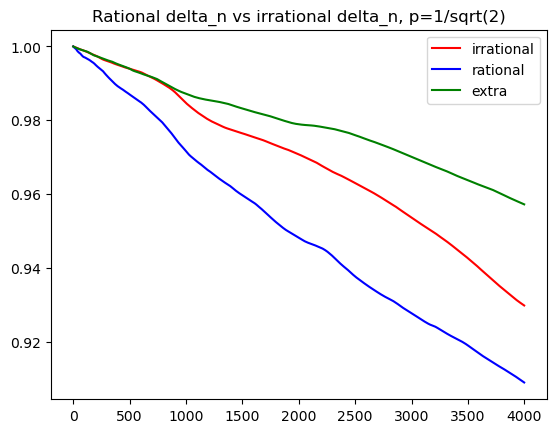

In [60]:
plt.plot(range(iteration_count), delta_n_1, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_3, c="b", label="rational")
plt.plot(range(iteration_count), delta_n_4, c="g", label="extra")
plt.title("Rational delta_n vs irrational delta_n, p=1/sqrt(2)")
plt.legend()

We now estimate $\tau$. We do that by finding a constant such that $\tau \geq \frac{n\Delta_n^2}{4}, \forall n \geq 1$

In [61]:
tau_irrational = mc.compute_observed_tau(delta_n_1)
tau_irrational

np.float64(864.6610938050444)

In [62]:
tau_rational = mc.compute_observed_tau(delta_n_3)
tau_rational

np.float64(826.3230446582781)

Now we plot the different $\Delta_n$ against $\sqrt{\frac{4\tau}{n}}$, where 

/var/folders/22/_dymvqsd4tgfb0zzj_kpnj340000gn/T/ipykernel_9487/238708958.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]


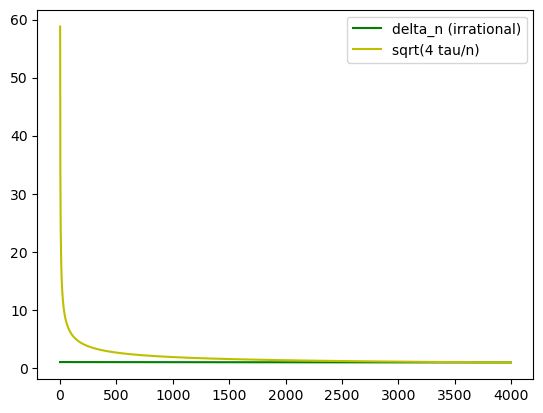

In [63]:
plt.plot(range(iteration_count), delta_n_1, c="g", label="delta_n (irrational)")
tau_series = [np.sqrt(4*tau_irrational/n) for n in range(0, iteration_count, 1)]
plt.plot(range(iteration_count), tau_series, c='y', label="sqrt(4 tau/n)")
plt.legend()

The $\Delta_n$ and $\tau$ computed above were found for $p_\text{rational} = 0.7$ and $p_\text{irrational} = \frac{1}{\sqrt 2}$. $\newline$ 
To observe if the constants scale with probabilities and if the convergence time of $\Delta_n$ is affected heavily by the transition probabilities, we now compute the same values for $p_\text{rational} = 0.35$ and $p_\text{irrational} = \frac{1}{\sqrt 8}$. $\newline$
We set $m_1 = -13, m_2 = 7$ to solve $m_1 \cdot 0.35 + m_2 \cdot 0.65 = 0$.

In [64]:
p_rational = 0.35
p_irrational = 1/np.sqrt(8)
m_1_rational, m_2_rational = mc.find_opt_int(N, p_rational)
m_1_irrational, m_2_irrational = mc.find_opt_int(N, p_irrational)

In [65]:
delta_n_irrational = mc.compute_delta_paper(N, p_irrational, m_1_irrational, m_2_irrational, number_deltas, iteration_count) 
delta_n_rational = mc.compute_delta_paper(N, p_rational, m_1_rational, m_2_rational, number_deltas, iteration_count) 

0.35355339059327373
0.35


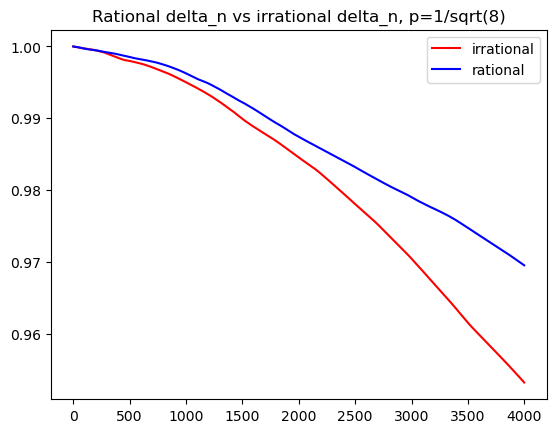

In [66]:
plt.plot(range(iteration_count), delta_n_irrational, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_rational, c="b", label="rational")
plt.title("Rational delta_n vs irrational delta_n, p=1/sqrt(8)")
plt.legend()

In [38]:
tau_small_irrational = mc.compute_observed_tau(delta_n_irrational)
tau_small_rational = mc.compute_observed_tau(delta_n_rational)
print("Irrational tau: ", tau_small_irrational)
print("Rational tau: ", tau_small_rational)

Irrational tau:  72.76951151828659
Rational tau:  90.9795008622623


We observe a sizeable difference between $\tau_\text{rational}$ and $\tau_\text{irrational}$! We now try again with even smaller p values.

In [44]:
p_irrational_2 = 1/np.sqrt(200)
p_rational_2 = 0.07
m_1_rational_2, m_2_rational_2 = mc.find_opt_int(N, p_rational_2)
m_1_irrational_2, m_2_irrational_2 = mc.find_opt_int(N, p_irrational_2)

In [45]:
print(m_1_irrational_2)

99


In [46]:
print(m_2_irrational_2)

0


In [47]:
delta_n_irrational_2 = mc.compute_delta_paper(N, p_irrational_2, m_1_irrational_2, m_2_irrational_2, number_deltas, iteration_count) 
delta_n_rational_2 = mc.compute_delta_paper(N, p_rational_2, m_1_rational_2, m_2_rational_2, number_deltas, iteration_count) 

0.07071067811865475
0.07


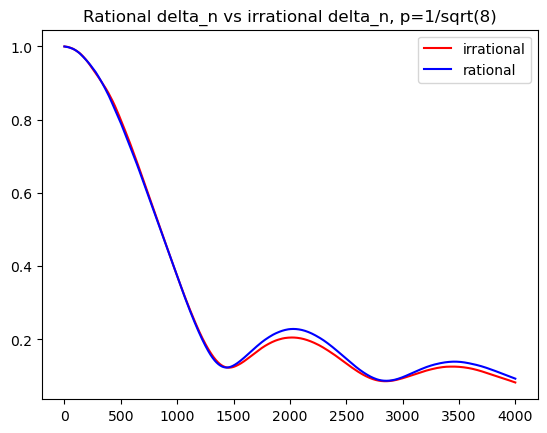

In [48]:
plt.plot(range(iteration_count), delta_n_irrational_2, c="r", label="irrational")
plt.plot(range(iteration_count), delta_n_rational_2, c="b", label="rational")
plt.title("Rational delta_n vs irrational delta_n, p=1/sqrt(8)")
plt.legend()

In [49]:
tau_small_irrational_2 = mc.compute_observed_tau(delta_n_irrational_2)
tau_small_rational_2 = mc.compute_observed_tau(delta_n_rational_2)
print("Irrational tau: ", tau_small_irrational)
print("Rational tau: ", tau_small_rational)

Irrational tau:  72.76951151828659
Rational tau:  90.9795008622623


We now compute the exact value of $\tau$.
We begin by computing the respective transition matrices $P_{rational}$ and $P_{irrational}$. For each matrix, respectively compute $L = I-P$ and then the second smallest singular value $\gamma$. As in the paper, we define the relaxation time of the chain by $\tau = \frac{1}{\gamma}$.

We tried to compute $\tau$ by directly creating a transition matrix and computing all the singular values but that did not work out very well because the transition matrix is $O(N^4)$ in storage relative to its input, and the algorithm to compute SVD values is $O(N^3)$ in its input, so all in all we would be looking at an $O(N^{12})$ time algorithm which, for N=100 already, is... huge.

So we used sparse matrices and scipy svds magic to make everything work, which took a bit of optimization work.

In [50]:
# computations 
irrational_tau = mc.compute_tau(N, p_1)
rational_tau = mc.compute_tau(N, p_2) 
print("Rational tau for transition probabilities 0.7: ", irrational_tau)
print("Irrational tau for transition probabilities 1/sqrt(2): ", rational_tau)

Rational tau for transition probabilities 0.7:  117.14753456684551
Irrational tau for transition probabilities 1/sqrt(2):  135.5756574364922


In [54]:
theoretical_small_rational_tau = mc.compute_tau(N, p_rational)
theoretical_small_irrational_tau = mc.compute_tau(N, p_irrational)

print("Rational tau for transition probability 0.35: ", theoretical_small_rational_tau)
print("Irrational tau for transition probability 1/sqrt(8): ", theoretical_small_irrational_tau)

Rational tau for transition probability 0.35:  197.4065141745608
Irrational tau for transition probability 1/sqrt(8):  181.48909754319084


Now we simulate the value of $\tau$ as N grows for both $p=\frac{1}{\sqrt{2}}$ and $p = \frac{1}{2}$, in order to show whether there is a difference in curve smoothness to show different orders of magnitudes for each case.

In [ ]:
N_values = range(20, 100)
rational_p = 0.7
irrational_p = 1/np.sqrt(2)

rational_tau_list = []
irrational_tau_list = []
for N in N_values:
    rational_tau_list.append(mc.compute_tau(N, rational_p))
    irrational_tau_list.append(mc.compute_tau(N, irrational_p))
    print("tau number ", N, " finished computing")

tau number  20  finished computing
tau number  21  finished computing
tau number  22  finished computing
tau number  23  finished computing
tau number  24  finished computing
tau number  25  finished computing
tau number  26  finished computing
tau number  27  finished computing
tau number  28  finished computing
tau number  29  finished computing
tau number  30  finished computing
tau number  31  finished computing
tau number  32  finished computing
tau number  33  finished computing
tau number  34  finished computing
tau number  35  finished computing
tau number  36  finished computing
tau number  37  finished computing
tau number  38  finished computing
tau number  39  finished computing
tau number  40  finished computing
tau number  41  finished computing
tau number  42  finished computing
tau number  43  finished computing
tau number  44  finished computing
tau number  45  finished computing
tau number  46  finished computing
tau number  47  finished computing
tau number  48  fini

Text(0, 0.5, 'tau')

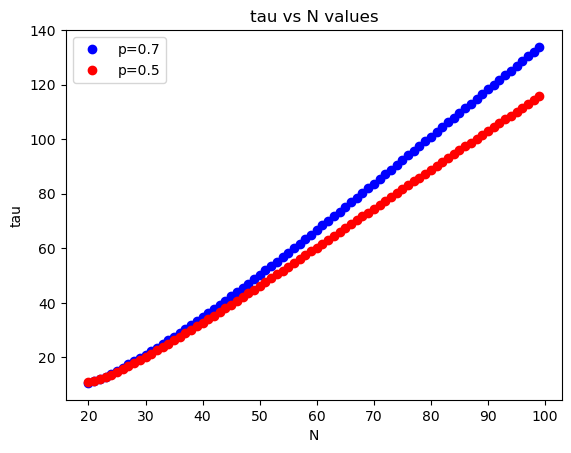

In [19]:
plt.plot(N_values, rational_tau_list, "o", c="b", label="p=0.7")
plt.plot(N_values, irrational_tau_list, "o", c="r", label="p=0.5")
plt.legend()
plt.title("tau vs N values")
plt.xlabel("N")
plt.ylabel("tau")

In [20]:
N_values = range(101, 150)
rational_p = 0.7
irrational_p = 1/np.sqrt(2)

rational_tau_list = []
irrational_tau_list = []
for N in N_values:
    rational_tau_list.append(compute_tau(N, rational_p))
    irrational_tau_list.append(compute_tau(N, irrational_p))
    print("tau number ", N, " finished computing")

tau number  101  finished computing
tau number  102  finished computing
tau number  103  finished computing
tau number  104  finished computing
tau number  105  finished computing
tau number  106  finished computing
tau number  107  finished computing
tau number  108  finished computing
tau number  109  finished computing
tau number  110  finished computing
tau number  111  finished computing
tau number  112  finished computing
tau number  113  finished computing
tau number  114  finished computing
tau number  115  finished computing
tau number  116  finished computing
tau number  117  finished computing
tau number  118  finished computing
tau number  119  finished computing
tau number  120  finished computing
tau number  121  finished computing
tau number  122  finished computing
tau number  123  finished computing
tau number  124  finished computing
tau number  125  finished computing
tau number  126  finished computing
tau number  127  finished computing
tau number  128  finished co

Text(0, 0.5, 'tau')

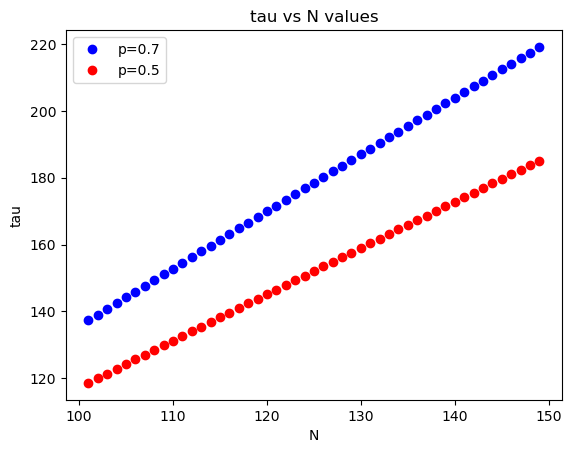

In [21]:
plt.plot(N_values, rational_tau_list, "o", c="b", label="p=0.7")
plt.plot(N_values, irrational_tau_list, "o", c="r", label="p=0.5")
plt.legend()
plt.title("tau vs N values")
plt.xlabel("N")
plt.ylabel("tau")